In [87]:
import re
import os
from pathlib import Path
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [128]:
def return_loss_profile_from_out_files_in_given_directory(directory):

    epochs = []
    train_total_losses = []
    train_geo_losses = []
    train_binary_cross_entropy = []
    valid_total_losses = []
    valid_geo_losses = []
    valid_binary_cross_entropy = []
    
    for p in directory.glob("*.out"):
        file_string = str(p)
        with open(p, 'r') as file:
            for line_number, line in enumerate(file, start=1):
                # print(line.strip())  # .strip() removes newline characters
                if re.search(r'\btra_loss=\b', line, re.IGNORECASE):
                    # print(f"Line {line_number}: Found 'train' -> {line.strip()}")
                    result = re.split(r"[ep ;:;=;,;\n]", line)
                    # print("train result", result)
                    train_total_losses.append( float(result[6]))
                    train_geo_losses.append(float(result[10]))
                    train_binary_cross_entropy.append(float(result[13]))
                    epochs.append(int(result[3]))
                    # print("train - geodesic loss:",  float(result[6]))
    
                if re.search(r'\bval_loss=\b', line, re.IGNORECASE):
                    # print(f"Line {line_number}: Found 'valid' -> {line.strip()}")
                    result = re.split(r"[ep ;:;=;,;\n]", line)
                    # print("valid result", result)             
    
                    valid_total_losses.append( float(result[6]))
                    valid_geo_losses.append(float(result[10]))
                    valid_binary_cross_entropy.append(float(result[13]))
                    # print("valid - geodesic loss:",  float(result[1]))
                    
    
    # print("valid_total_losses\n", valid_total_losses)
    
    # Zip the lists together
    combined = list(zip(epochs, train_total_losses, train_geo_losses, train_binary_cross_entropy, valid_total_losses, valid_geo_losses, valid_binary_cross_entropy))
    
    # print("combined\n", combined)
    
    # Sort by epoch (first element of each tuple)
    combined.sort(key=lambda x: x[0])
    
    # Unzip back into separate lists
    epochs, train_total_losses, train_geo_losses, train_binary_cross_entropy, valid_total_losses, valid_geo_losses, valid_binary_cross_entropy = map(list, zip(*combined))

    return epochs, train_total_losses, train_geo_losses, train_binary_cross_entropy, valid_total_losses, valid_geo_losses, valid_binary_cross_entropy

def return_kdes_based_on_given_dataset(geodesic_distances, lower_bound, upper_bound):
    kde_trained = gaussian_kde(geodesic_distances)
    x_grid = np.linspace(lower_bound-0.01, upper_bound+0.01, 1000)
    kde_values_trained = kde_trained(x_grid)

    return kde_values_trained,x_grid


def return_mean_and_standard_error_for_prediction(binary_correct):

    N = len(binary_correct)
    p = np.mean(binary_correct)
    
    # Standard error of the accuracy estimate
    p_err = np.sqrt(p * (1.0 - p) / N)

    return p, p_err

In [76]:
# trained_model_indicator_index = "sing_02"



base_dir_path = os.getcwd() + "/"

train_index = 1
loss_profile_path_1 = base_dir_path + "independent_run_0%d"%(train_index)
directory_1 = Path(loss_profile_path_1)
epochs_1, train_total_losses_1, train_geo_losses_1, train_binary_cross_entropy_1, valid_total_losses_1, valid_geo_losses_1, valid_binary_cross_entropy_1 = return_loss_profile_from_out_files_in_given_directory(directory_1)


train_index = 2
loss_profile_path_2 = base_dir_path + "independent_run_0%d"%(train_index)
directory_2 = Path(loss_profile_path_2)
epochs_2, train_total_losses_2, train_geo_losses_2, train_binary_cross_entropy_2, valid_total_losses_2, valid_geo_losses_2, valid_binary_cross_entropy_2 = return_loss_profile_from_out_files_in_given_directory(directory_2)

train_index = 3
loss_profile_path_3 = base_dir_path + "independent_run_0%d"%(train_index)
directory_3 = Path(loss_profile_path_3)
epochs_3, train_total_losses_3, train_geo_losses_3, train_binary_cross_entropy_3, valid_total_losses_3, valid_geo_losses_3, valid_binary_cross_entropy_3 = return_loss_profile_from_out_files_in_given_directory(directory_3)

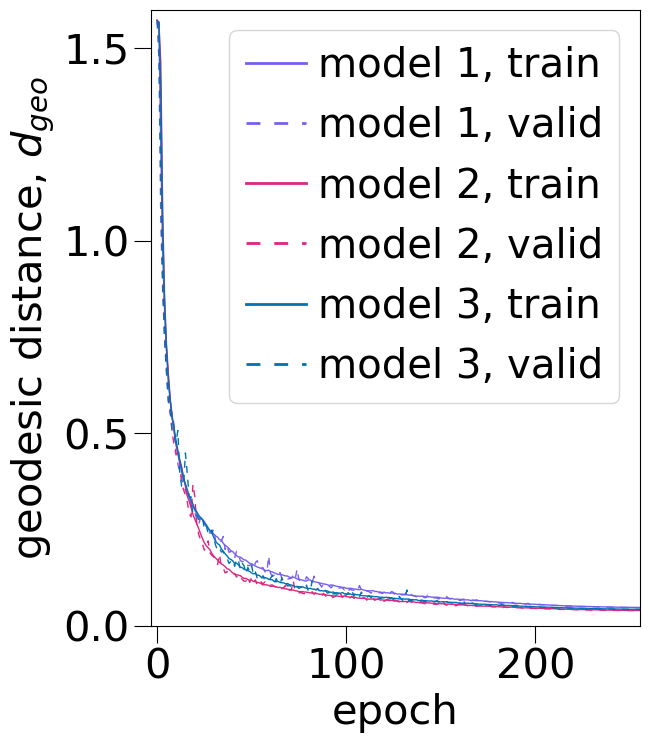

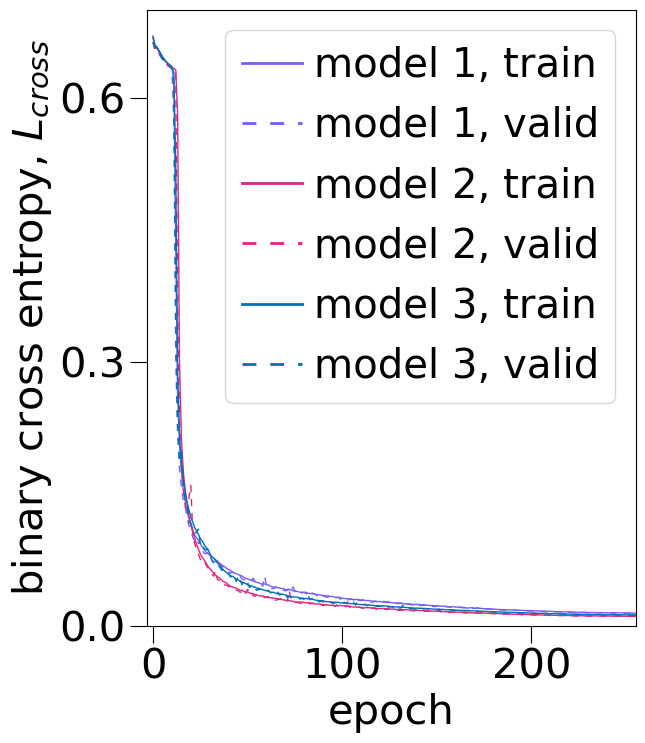

In [75]:
# OVERALL Loss evolution profile.
fig, ax = plt.subplots(1, 1, figsize=(6.3, 8))
ax.plot(epochs_1, train_geo_losses_1, color = '#785EF0', linewidth = 1.0,  label=r'model 1, train')
ax.plot(epochs_1, valid_geo_losses_1, color = '#785EF0', linewidth = 1.0, linestyle = (0, (5, 5)), label=r'model 1, valid')
ax.plot(epochs_2, train_geo_losses_2, color = '#DC267F', linewidth = 1.0, label=r'model 2, train')
ax.plot(epochs_2, valid_geo_losses_2, color = '#DC267F', linewidth = 1.0, linestyle = (0, (5, 5)), label=r'model 2, valid')
ax.plot(epochs_3, train_geo_losses_3, color = '#0072B2', linewidth = 1.0, label=r'model 3, train')
ax.plot(epochs_3, valid_geo_losses_3, color = '#0072B2', linewidth = 1.0, linestyle = (0, (5, 5)), label=r'model 3, valid')
ax.set_xlabel(r"epoch", fontsize = 30)
ax.set_ylabel(r"geodesic distance, $d_{geo}$", fontsize = 30)

leg = ax.legend(fontsize=29, ncol=1, handlelength=1.5, handletextpad=0.3, columnspacing = 0.4)
for line in leg.get_lines():
    line.set_linewidth(2.0)  # Increase or decrease this value to your liking
ax.set_xlim([-3,255])
ax.set_ylim([0.0,1.6])
ax.set_yticks([0.0, 0.5, 1.0, 1.5])
# formatter = ScalarFormatter(useOffset=False) # useOffset=False prevents an additional offset term
# formatter.set_powerlimits((-2, -2)) # Force scientific notation for numbers within 10^-3 to 10^-3
# formatter.set_scientific(True) # Ensure scientific notation is used
# ax.yaxis.set_major_formatter(formatter)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=30)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=30)
plt.savefig(base_dir_path + "evolution_of_geodesic_losses_binaryMap.pdf", bbox_inches='tight')
plt.show()

# OVERALL Loss evolution profile.
fig, ax = plt.subplots(1, 1, figsize=(6.3, 8))
ax.plot(epochs_1, train_binary_cross_entropy_1, color = '#785EF0', linewidth = 1.0,  label=r'model 1, train')
ax.plot(epochs_1, valid_binary_cross_entropy_1, color = '#785EF0', linewidth = 1.0, linestyle = (0, (5, 5)), label=r'model 1, valid')
ax.plot(epochs_2, train_binary_cross_entropy_2, color = '#DC267F', linewidth = 1.0, label=r'model 2, train')
ax.plot(epochs_2, valid_binary_cross_entropy_2, color = '#DC267F', linewidth = 1.0, linestyle = (0, (5, 5)), label=r'model 2, valid')
ax.plot(epochs_3, train_binary_cross_entropy_3, color = '#0072B2', linewidth = 1.0, label=r'model 3, train')
ax.plot(epochs_3, valid_binary_cross_entropy_3, color = '#0072B2', linewidth = 1.0, linestyle = (0, (5, 5)), label=r'model 3, valid')
ax.set_xlabel(r"epoch", fontsize = 30)
ax.set_ylabel(r"binary cross entropy, $L_{cross}$", fontsize = 30)
leg = ax.legend(fontsize=29, ncol=1, handlelength=1.5, handletextpad=0.3, columnspacing = 0.4)
# Loop through the line objects in the legend and set a new thickness
for line in leg.get_lines():
    line.set_linewidth(2.0)  # Increase or decrease this value to your liking
ax.set_xlim([-3,255])
ax.set_ylim([0.0,0.7])
ax.set_yticks([0.0, 0.3, 0.6])
# formatter = ScalarFormatter(useOffset=False) # useOffset=False prevents an additional offset term
# formatter.set_powerlimits((-2, -2)) # Force scientific notation for numbers within 10^-3 to 10^-3
# formatter.set_scientific(True) # Ensure scientific notation is used
# ax.yaxis.set_major_formatter(formatter)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=30)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=30)
plt.savefig(base_dir_path + "evolution_of_cross_entropy_binaryMap.pdf", bbox_inches='tight')
plt.show()



In [85]:
summaryFileString = "validation_per_sample_metrics_best_model.npz"

model_1_summary_npz = np.load(str(directory_1) + "/" + summaryFileString)
geodesic_distance_1 = model_1_summary_npz["geodesic_distance_stack"]
binary_correct_1 = model_1_summary_npz["binary_prediction_accuracy_stack"]

model_2_summary_npz = np.load(str(directory_2) + "/" + summaryFileString)
geodesic_distance_2 = model_2_summary_npz["geodesic_distance_stack"]
binary_correct_2 = model_2_summary_npz["binary_prediction_accuracy_stack"]

model_3_summary_npz = np.load(str(directory_3) + "/" + summaryFileString)
geodesic_distance_3 = model_3_summary_npz["geodesic_distance_stack"]
binary_correct_3 = model_3_summary_npz["binary_prediction_accuracy_stack"]

In [86]:
geodesic_max_bound = np.max([np.max(geodesic_distance_1),np.max(geodesic_distance_2),np.max(geodesic_distance_3)])
geodesic_min_bound = np.min([np.min(geodesic_distance_1),np.min(geodesic_distance_2),np.min(geodesic_distance_3)])

In [93]:
kde_values_trained_1, x_grid_1 = return_kdes_based_on_given_dataset(geodesic_distance_1, geodesic_min_bound, geodesic_max_bound)
kde_values_trained_2, x_grid_2 = return_kdes_based_on_given_dataset(geodesic_distance_2, geodesic_min_bound, geodesic_max_bound)
kde_values_trained_3, x_grid_3 = return_kdes_based_on_given_dataset(geodesic_distance_3, geodesic_min_bound, geodesic_max_bound)


Peak location_trained_1: 0.009020002
Peak location_trained_2: 0.009020002
Peak location_trained_3: 0.009020002


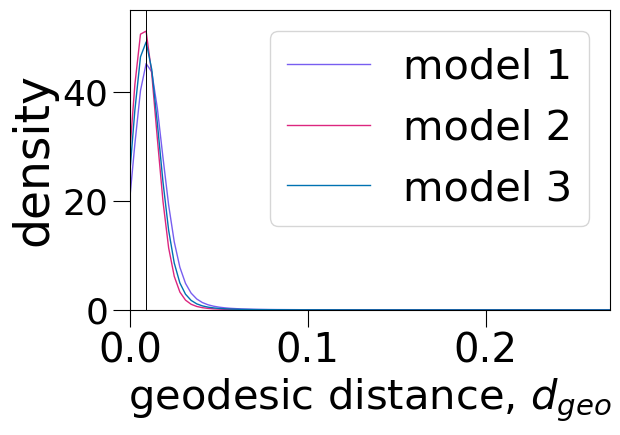

In [135]:

# Find the peak (location of maximum density)
peak_location_trained_1 = x_grid_1[np.argmax(kde_values_trained_1)]
print("Peak location_trained_1:", peak_location_trained_1)

peak_location_trained_2 = x_grid_2[np.argmax(kde_values_trained_2)]
print("Peak location_trained_2:", peak_location_trained_2)

peak_location_trained_3 = x_grid_3[np.argmax(kde_values_trained_3)]
print("Peak location_trained_3:", peak_location_trained_3)


# Optional: plot
# fig, ax = plt.subplots(1, 1, figsize=(7.3, 5))
fig = plt.figure(figsize=(6, 4))
ax = fig.add_axes([0.15, 0.15, 0.8, 0.75])  # adjust these numbers to control the axes box

ax.plot(x_grid_1, kde_values_trained_1, label="model 1", color = "#785EF0", linewidth = 1.0)
ax.plot(x_grid_2, kde_values_trained_2, label="model 2", color = "#DC267F", linewidth = 1.0)
ax.plot(x_grid_3, kde_values_trained_3, label="model 3", color = "#0072B2", linewidth = 1.0)
ax.axvline(peak_location_trained_1, color="#000000", linestyle="solid", linewidth = 0.7)

# ax.fill_between(x_grid, kde_values_trained, alpha=0.15, color = "#E67300")
# ax.fill_between(x_grid, kde_values_untrained, alpha=0.08, color = "#0066CC")

ax.legend(fontsize = 30)
ax.set_xlim([0.0, 0.27])
ax.set_ylim([-0.01,55])
ax.set_yticks([0.0, 20, 40])
ax.set_xticks([0, 0.1, 0.2])
ax.set_xlabel(r"geodesic distance, $d_{geo}$", fontsize = 30)
ax.set_ylabel(r"density", fontsize = 34)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=29)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
# plt.title("1D KDE plot of geodesic distance (valid data)", fontsize=20)
plt.savefig(base_dir_path +  'kde_geodesic_valid_set.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [127]:
mean_1, standard_error_1 = return_mean_and_standard_error_for_prediction(binary_correct_1)
mean_2, standard_error_2 = return_mean_and_standard_error_for_prediction(binary_correct_2)
mean_3, standard_error_3 = return_mean_and_standard_error_for_prediction(binary_correct_3)

print(f"Prediction accuracy = {mean_1:.5f} ± {standard_error_1:.5f}")
print(f"Prediction accuracy = {mean_2:.5f} ± {standard_error_2:.5f}")
print(f"Prediction accuracy = {mean_3:.5f} ± {standard_error_3:.5f}")

Prediction accuracy = 0.99966 ± 0.00001
Prediction accuracy = 0.99976 ± 0.00001
Prediction accuracy = 0.99973 ± 0.00001
